In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# dir + name pattern you asked for: ../data/name
DATA_DIR = Path("../data")
name = "msl_2021novdec.nc"   # change this as needed
path = DATA_DIR / name

ds = xr.open_dataset(path)  # lazy-loads; doesn't read everything into RAM
ds


<xarray.Dataset> Size: 6GB
Dimensions:     (valid_time: 1464, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 12kB 2021-11-01 ... 2021-12-31T23...
    expver      (valid_time) <U4 23kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
Data variables:
    msl         (valid_time, latitude, longitude) float32 6GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-20T23:31 GRIB to CDM+CF via cfgrib-0.9.1...

In [45]:
v = ds["msl"]

# 1) What xarray thinks the on-disk chunking is (best first check)
print("encoding.chunksizes:", v.encoding.get("chunksizes"))
print("encoding.preferred_chunks:", v.encoding.get("preferred_chunks"))

# 2) If it’s opened as dask (chunks=...), you’ll see the chunk structure here
print("xarray .chunks:", v.chunks)              # None if not dask
print("dask chunks:", getattr(v.data, "chunks", None))


encoding.chunksizes: (183, 91, 180)
encoding.preferred_chunks: {'valid_time': 183, 'latitude': 91, 'longitude': 180}
xarray .chunks: None
dask chunks: None


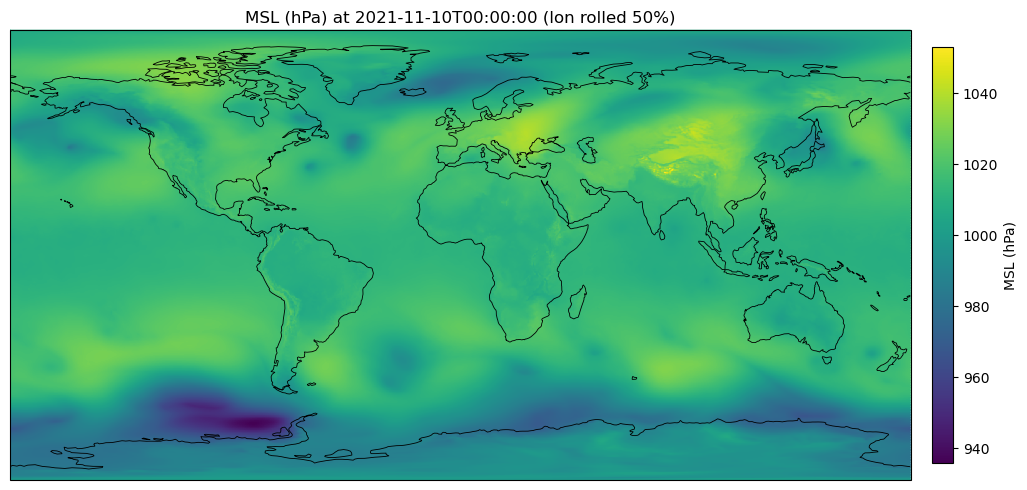

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

t = np.datetime64("2021-11-10T00:00:00")

if "valid_time" not in ds.coords:
    raise KeyError(f"No 'valid_time' coordinate. Coords: {list(ds.coords)}")

if t not in ds["valid_time"].values:
    t0 = str(ds["valid_time"].values[0])
    t1 = str(ds["valid_time"].values[-1])
    raise ValueError(f"{t} not found in valid_time. Range: {t0} .. {t1}")

msl = ds["msl"].sel(valid_time=t)

# Pa -> hPa
msl_hpa = msl / 100.0

# roll lon by 50% so seam moves (1440 -> shift 720)
nlon = msl_hpa.sizes["longitude"]
msl_hpa = msl_hpa.roll(longitude=nlon // 2, roll_coords=True)
msl_hpa = msl_hpa.sortby("longitude")

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=proj)

im = ax.pcolormesh(
    msl_hpa["longitude"],
    msl_hpa["latitude"],
    msl_hpa.values,
    transform=ccrs.PlateCarree(),
    shading="auto",
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
ax.set_global()

cb = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, shrink=0.9)
cb.set_label("MSL (hPa)")

ax.set_title(f"MSL (hPa) at {str(t)} (lon rolled 50%)")
plt.show()


In [42]:
msl / 100

<xarray.DataArray 'msl' (latitude: 721, longitude: 1440)> Size: 4MB
array([[1006.52313, 1006.52313, 1006.52313, ..., 1006.52313, 1006.52313,
        1006.52313],
       [1006.5631 , 1006.5581 , 1006.5556 , ..., 1006.5731 , 1006.5681 ,
        1006.5656 ],
       [1006.59314, 1006.58563, 1006.5806 , ..., 1006.6131 , 1006.60565,
        1006.59814],
       ...,
       [ 999.3831 ,  999.3806 ,  999.3756 , ...,  999.3906 ,  999.3856 ,
         999.3831 ],
       [ 999.3306 ,  999.3256 ,  999.3206 , ...,  999.33813,  999.33563,
         999.3331 ],
       [ 999.8681 ,  999.8681 ,  999.8681 , ...,  999.8681 ,  999.8681 ,
         999.8681 ]], shape=(721, 1440), dtype=float32)
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2021-11-10
    expver      <U4 16B ...
Attributes: (12/32)
    GRIB_paramId:                             151
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               Pa
    long_name:                                Mean sea level pressure
    units:                                    Pa
    standard_name:                            air_pressure_at_mean_sea_level
    GRIB_surface:                             0.0

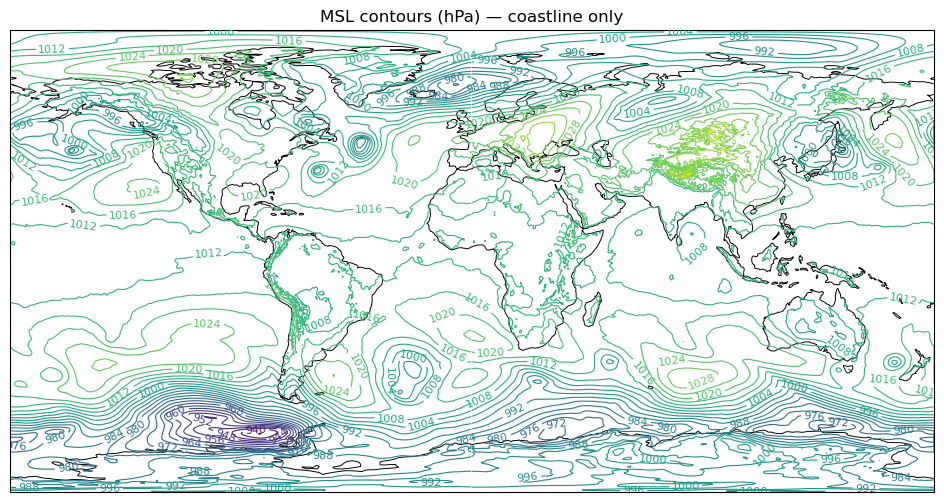

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=proj)

vmin = float(msl_hpa.min())
vmax = float(msl_hpa.max())
step = 4.0
levels = np.arange(np.floor(vmin / step) * step, np.ceil(vmax / step) * step + step, step)

cs = ax.contour(
    msl_hpa["longitude"].values,
    msl_hpa["latitude"].values,
    msl_hpa.values,
    levels=levels,
    transform=ccrs.PlateCarree(),
    linewidths=0.8,
)

ax.clabel(cs, inline=True, fontsize=8, fmt="%.0f")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.set_global()
ax.set_title("MSL contours (hPa) — coastline only")
plt.show()


In [34]:
wind_ds

<xarray.Dataset> Size: 36GB
Dimensions:         (valid_time: 1464, pressure_level: 2, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 12kB 2021-11-01 ... 2021-12-3...
    expver          (valid_time) <U4 23kB ...
  * pressure_level  (pressure_level) float64 16B 1e+03 925.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B ...
Data variables:
    q               (valid_time, pressure_level, latitude, longitude) float32 12GB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 12GB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 12GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-19T22:59 GRIB to CDM+CF via cfgrib-0.9.1...

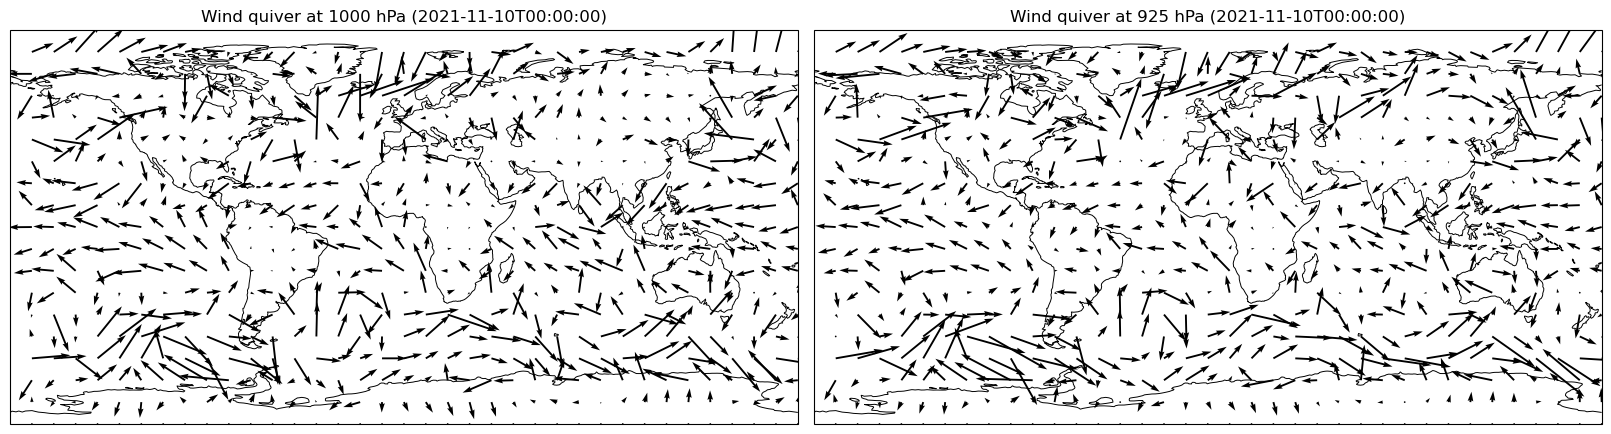

In [37]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

# assumes t already exists (from your earlier cells)
wind_path = Path("../data") / "specifichumidity_wind_1000-925hpa_2026-02-19.nc"
wind_ds = xr.open_dataset(wind_path)

time_coord = "valid_time" if "valid_time" in wind_ds.coords else "time"
level_coord = "pressure_level" if "pressure_level" in wind_ds.coords else "level"
lat_name = "latitude" if "latitude" in wind_ds.coords else "lat"
lon_name = "longitude" if "longitude" in wind_ds.coords else "lon"

u_name = next((k for k in ["u", "u_component_of_wind"] if k in wind_ds.data_vars), None)
v_name = next((k for k in ["v", "v_component_of_wind"] if k in wind_ds.data_vars), None)
if u_name is None or v_name is None:
    raise KeyError(f"Couldn't find u/v in data_vars. data_vars: {list(wind_ds.data_vars)}")

for L in (1000, 925):
    if L not in wind_ds[level_coord].values:
        raise ValueError(f"{L} hPa not found in {level_coord}. Levels: {wind_ds[level_coord].values}")

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={"projection": proj}, constrained_layout=True)

stride_lat, stride_lon = 40, 40

for ax, L in zip(axes, (1000, 925)):
    uL = wind_ds[u_name].sel({time_coord: t, level_coord: L})
    vL = wind_ds[v_name].sel({time_coord: t, level_coord: L})

    uL = uL.isel({lat_name: slice(None, None, stride_lat), lon_name: slice(None, None, stride_lon)})
    vL = vL.isel({lat_name: slice(None, None, stride_lat), lon_name: slice(None, None, stride_lon)})

    lats = uL[lat_name].values
    lons = uL[lon_name].values
    LON, LAT = np.meshgrid(lons, lats)

    ax.quiver(LON, LAT, uL.values, vL.values, transform=ccrs.PlateCarree(), linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.set_global()
    ax.set_title(f"Wind quiver at {L} hPa ({str(t)})")

plt.show()


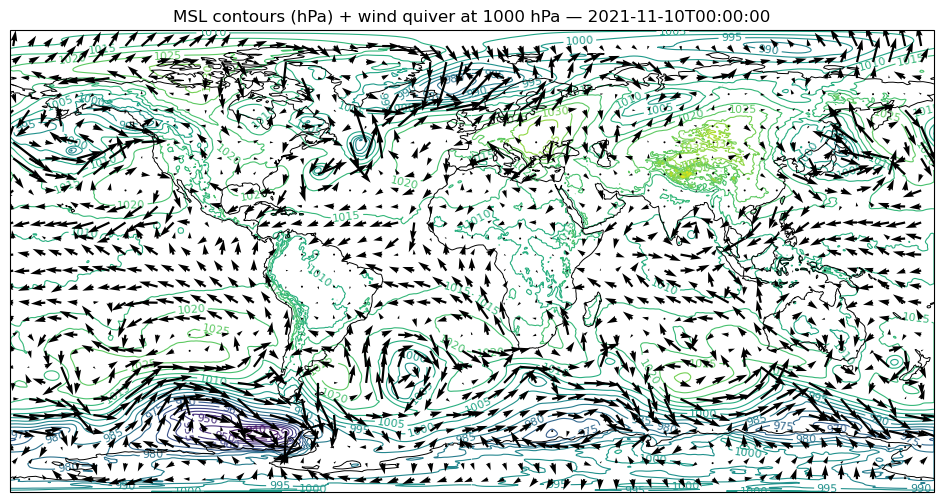

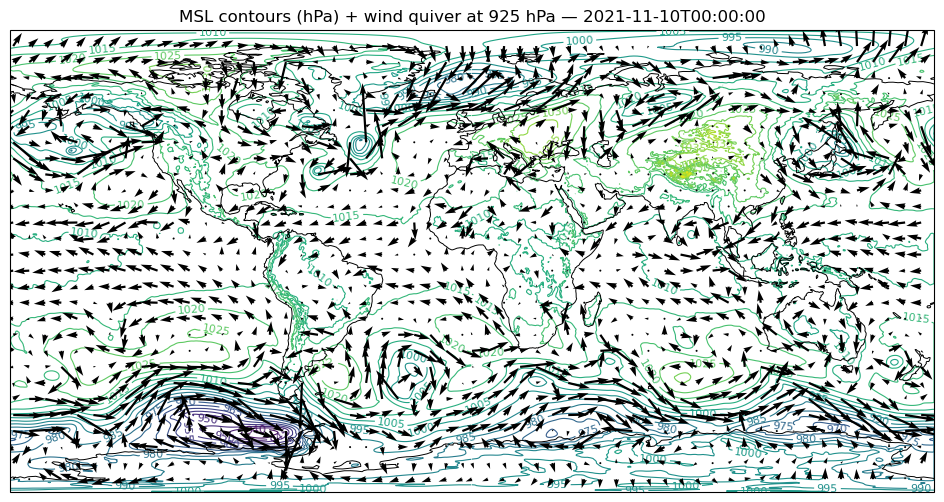

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# assumes:
# - msl_hpa already exists (and is lon-rolled + sorted as in your earlier cell)
# - wind_ds exists (from the wind file cell)
# - t exists
# - time_coord, level_coord, lat_name, lon_name, u_name, v_name exist (from the wind file cell)

stride_lat, stride_lon = 25, 25

for L in (1000, 925):
    # wind at level
    uL = wind_ds[u_name].sel({time_coord: t, level_coord: L})
    vL = wind_ds[v_name].sel({time_coord: t, level_coord: L})

    uL = uL.isel({lat_name: slice(None, None, stride_lat), lon_name: slice(None, None, stride_lon)})
    vL = vL.isel({lat_name: slice(None, None, stride_lat), lon_name: slice(None, None, stride_lon)})

    # lon-roll wind to match msl_hpa seam shift (assumes same lon dim length)
    nlon_w = uL.sizes[lon_name]
    uL = uL.roll({lon_name: nlon_w // 2}, roll_coords=True).sortby(lon_name)
    vL = vL.roll({lon_name: nlon_w // 2}, roll_coords=True).sortby(lon_name)

    lats = uL[lat_name].values
    lons = uL[lon_name].values
    LON, LAT = np.meshgrid(lons, lats)

    # MSL contours
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(14, 6))
    ax = plt.axes(projection=proj)

    vmin = float(msl_hpa.min())
    vmax = float(msl_hpa.max())
    step = 5.0
    levels = np.arange(np.floor(vmin / step) * step, np.ceil(vmax / step) * step + step, step)

    cs = ax.contour(
        msl_hpa["longitude"].values,
        msl_hpa["latitude"].values,
        msl_hpa.values,
        levels=levels,
        transform=ccrs.PlateCarree(),
        linewidths=0.8,
    )
    ax.clabel(cs, inline=True, fontsize=8, fmt="%.0f")

    # wind quiver overlay
    ax.quiver(
        LON, LAT,
        uL.values, vL.values,
        transform=ccrs.PlateCarree(),
        linewidth=0.5,
        zorder=5,
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=6)
    ax.set_global()
    ax.set_title(f"MSL contours (hPa) + wind quiver at {L} hPa — {str(t)}")
    plt.show()
